<a href="https://colab.research.google.com/github/bah862696-coder/DI-Bootcamp/blob/master/DayChallenge_W7_D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Défi quotidien : Analyse textuelle de livres à l'aide d'un nuage de mots

Ce notebook contient la solution complète à l'exercice d'analyse textuelle de livres. Il couvre le prétraitement du texte, l'analyse des fréquences de mots à l'aide de Bag of Words et l'identification des termes importants à l'aide de TF-IDF.

## Configuration initiale: Installation des bibliothèques et téléchargement des ressources NLP

In [5]:
# Installation des bibliothèques nécessaires
%pip install nltk spacy requests matplotlib wordcloud scikit-learn
# Téléchargement du modèle spaCy (utilisation de ! pour une commande shell)
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 111.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [6]:
# Importations générales
import requests
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Importations NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Importations spaCy
import spacy

# Importations scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Téléchargement direct des ressources NLTK requises
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

print("Toutes les bibliothèques et ressources NLTK sont prêtes.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_n

Toutes les bibliothèques et ressources NLTK sont prêtes.


[nltk_data]   Unzipping corpora/words.zip.


## Partie 1 — Prétraitement du texte

### 1.1 Création de la fonction `load_texts()`

In [3]:
def load_texts(urls):
    """
    Télécharge les livres à partir d'une liste d'URLs, nettoie le texte
    et retourne une liste de textes nettoyés.

    Args:
        urls (list): Liste des URLs des livres à télécharger.

    Returns:
        list: Une liste de chaînes de caractères, chaque chaîne étant le texte nettoyé d'un livre.
    """
    cleaned_texts = []
    for url in urls:
        try:
            response = requests.get(url)
            response.raise_for_status() # Lève une exception pour les codes d'état HTTP erronés
            text = response.text

            # Nettoyage initial: suppression des caractères non-mots, caractères spéciaux et espaces multiples
            # Convertir en minuscules pour une meilleure uniformité
            text = text.lower()

            # Supprimer tout ce qui est entre <doc> et </doc> (balises XML/HTML si présentes)
            text = re.sub(r'<doc>.*?</doc>', '', text, flags=re.DOTALL)

            # Supprimer les balises HTML/XML restantes
            text = re.sub(r'<[^>]+>', '', text)

            # Supprimer les sauts de page (Ctrl+L caractère ASCII 12)
            text = text.replace('\f', '')

            # Supprimer les lignes vides ou avec seulement des espaces
            text = re.sub(r'\n\s*\n', '\n', text)

            # Remplacer les tirets en fin de ligne par un espace
            text = re.sub(r'-\n', ' ', text)

            # Remplacer les retours à la ligne par des espaces pour former des paragraphes continus
            text = re.sub(r'\n', ' ', text)

            # Supprimer les multiples espaces
            text = re.sub(r'\s+', ' ', text).strip()

            cleaned_texts.append(text)

        except requests.exceptions.RequestException as e:
            print(f"Erreur lors du téléchargement de {url}: {e}")
        except Exception as e:
            print(f"Une erreur inattendue est survenue lors du traitement de {url}: {e}")

    return cleaned_texts

# URLs des livres de Project Gutenberg
book_urls = [
    "https://www.gutenberg.org/files/11/11-0.txt", # Alice's Adventures in Wonderland
    "https://www.gutenberg.org/files/12/12-0.txt", # Through the Looking-Glass
    "https://www.gutenberg.org/files/57/57-0.txt"  # A Tangled Tale
]

corpus = load_texts(book_urls)

print(f"Nombre de documents chargés et nettoyés: {len(corpus)}")


Nombre de documents chargés et nettoyés: 3


### 1.2 Afficher les 200 premiers caractères et nettoyer les bordures

In [4]:
cleaned_corpus = []
for i, text in enumerate(corpus):
    print(f"\n--- Livre {i+1} (avant nettoyage des bordures) ---")
    print(text[:200])

    # Supprimer tout ce qui précède '*** start of'
    start_marker = '*** start of'
    if start_marker in text:
        text = text.split(start_marker, 1)[1]

    # Supprimer tout ce qui suit '*** end of'
    end_marker = '*** end of'
    if end_marker in text:
        text = text.split(end_marker, 1)[0]

    # Nettoyage supplémentaire des en-têtes/pieds de page génériques de gutenberg s'ils persistent
    # Parfois, il y a des textes comme 'project gutenberg' ou 'e-text' juste après le START OF
    text = re.sub(r'project gutenberg[\s\S]*?alice', 'alice', text, flags=re.IGNORECASE)
    text = re.sub(r'etext of[\s\S]*?by lewis carroll', '', text, flags=re.IGNORECASE)
    text = re.sub(r'production notes.*', '', text, flags=re.DOTALL)

    # Supprimer les multiples espaces après nettoyage des bordures
    text = re.sub(r'\s+', ' ', text).strip()

    cleaned_corpus.append(text)

    print(f"\n--- Livre {i+1} (après nettoyage des bordures) ---")
    print(text[:200])

corpus = cleaned_corpus


--- Livre 1 (avant nettoyage des bordures) ---
*** start of the project gutenberg ebook 11 *** [illustration] alice’s adventures in wonderland by lewis carroll the millennium fulcrum edition 3.0 contents chapter i. down the rabbit-hole chapter ii.

--- Livre 1 (après nettoyage des bordures) ---
the alice’s adventures in wonderland by lewis carroll the millennium fulcrum edition 3.0 contents chapter i. down the rabbit-hole chapter ii. the pool of tears chapter iii. a caucus-race and a long ta

--- Livre 2 (avant nettoyage des bordures) ---
*** start of the project gutenberg ebook 12 *** [illustration] through the looking-glass and what alice found there by lewis carroll the millennium fulcrum edition 1.7 dramatis personæ. (_as arranged 

--- Livre 2 (après nettoyage des bordures) ---
the alice found there by lewis carroll the millennium fulcrum edition 1.7 dramatis personæ. (_as arranged before commencement of game._) white red. pieces. pawns. pawns. pieces. tweedledee. daisy. dai

---

### 1.3 Tokenisation et affichage des premiers tokens

In [7]:
tokenized_corpus = []
for i, text in enumerate(corpus):
    tokens = word_tokenize(text)
    tokenized_corpus.append(tokens)
    print(f"\n--- Livre {i+1}: 150 premiers tokens ---")
    print(tokens[:150])


--- Livre 1: 150 premiers tokens ---
['the', 'alice', '’', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', '3.0', 'contents', 'chapter', 'i.', 'down', 'the', 'rabbit-hole', 'chapter', 'ii', '.', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', '.', 'a', 'caucus-race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', '.', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v.', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', '.', 'pig', 'and', 'pepper', 'chapter', 'vii', '.', 'a', 'mad', 'tea-party', 'chapter', 'viii', '.', 'the', 'queen', '’', 's', 'croquet-ground', 'chapter', 'ix', '.', 'the', 'mock', 'turtle', '’', 's', 'story', 'chapter', 'x.', 'the', 'lobster', 'quadrille', 'chapter', 'xi', '.', 'who', 'stole', 'the', 'tarts', '?', 'chapter', 'xii', '.', 'alice', '’', 's', 'evidence', 'chapter', 'i.', 'down', 'the', 'rabbit-hole', 'alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting',

### 1.4 Suppression des mots vides (Stopwords)

In [8]:
stop_words = set(stopwords.words('english'))
# Ajout de ponctuation aux stopwords pour un nettoyage plus propre
import string
stop_words.update(list(string.punctuation))
stop_words.update(['’', '‘', '“', '”', '—'])

filtered_corpus = []
for i, tokens in enumerate(tokenized_corpus):
    filtered = [w for w in tokens if not w.lower() in stop_words]
    filtered_corpus.append(filtered)

    print(f"\n--- Vérification pour le Livre {i+1} ---")
    check_words = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']
    for word in check_words:
        count = filtered.count(word)
        print(f"Occurrences de '{word}': {count}")


--- Vérification pour le Livre 1 ---
Occurrences de 'i': 0
Occurrences de 'me': 0
Occurrences de 'my': 0
Occurrences de 'myself': 0
Occurrences de 'we': 0
Occurrences de 'our': 0
Occurrences de 'ours': 0
Occurrences de 'ourselves': 0

--- Vérification pour le Livre 2 ---
Occurrences de 'i': 0
Occurrences de 'me': 0
Occurrences de 'my': 0
Occurrences de 'myself': 0
Occurrences de 'we': 0
Occurrences de 'our': 0
Occurrences de 'ours': 0
Occurrences de 'ourselves': 0

--- Vérification pour le Livre 3 ---
Occurrences de 'i': 0
Occurrences de 'me': 0
Occurrences de 'my': 0
Occurrences de 'myself': 0
Occurrences de 'we': 0
Occurrences de 'our': 0
Occurrences de 'ours': 0
Occurrences de 'ourselves': 0


### 1.5 Stemming avec PorterStemmer

In [9]:
stemmer = PorterStemmer()
stemmed_corpus = []

for i, tokens in enumerate(filtered_corpus):
    stemmed = [stemmer.stem(token) for token in tokens]
    stemmed_corpus.append(stemmed)
    print(f"\n--- Livre {i+1}: 50 premiers tokens racinisés (stemmed) ---")
    print(stemmed[:50])


--- Livre 1: 50 premiers tokens racinisés (stemmed) ---
['alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', '3.0', 'content', 'chapter', 'i.', 'rabbit-hol', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucus-rac', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v.', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea-parti', 'chapter', 'viii', 'queen', 'croquet-ground', 'chapter', 'ix', 'mock', 'turtl', 'stori', 'chapter']

--- Livre 2: 50 premiers tokens racinisés (stemmed) ---
['alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', '1.7', 'dramati', 'personæ', '_a', 'arrang', 'commenc', 'game._', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w.', 'queen', 'lily.', 'tiger-lili', 'r.', 'queen', 'w.', 'king', 'fawn', 'rose', 'r.', '

### 1.6 Lemmatisation avec spaCy

In [10]:
nlp = spacy.load("en_core_web_sm")
lemmatized_corpus = []

for i, text in enumerate(corpus):
    # spaCy traite le texte brut pour conserver le contexte
    doc = nlp(text)
    # On filtre les stopwords et la ponctuation comme demandé précédemment
    lemmas = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.text.strip() != ""]
    lemmatized_corpus.append(lemmas)
    print(f"\n--- Livre {i+1}: 50 premiers lemmes (spaCy) ---")
    print(lemmas[:50])


--- Livre 1: 50 premiers lemmes (spaCy) ---
['alice', 'adventure', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', '3.0', 'content', 'chapter', 'i.', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'little', 'bill', 'chapter', 'v.', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'party', 'chapter', 'viii', 'queen', 'croquet', 'ground', 'chapter', 'ix']

--- Livre 2: 50 premiers lemmes (spaCy) ---
['alice', 'find', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', '1.7', 'dramatis', 'personæ', 'arrange', 'commencement', 'game', 'white', 'red', 'piece', 'pawn', 'pawn', 'piece', 'tweedledee', 'daisy', 'daisy', 'humpty', 'dumpty', 'unicorn', 'haigha', 'messenger', 'carpenter', 'sheep', 'oyster', 'oyster', 'walrus', 'w.', 'queen', 'lily', 'tiger', 'lily', 'r.', 'queen', 'w.', 'king', 'fawn', 'rise', 'r.', 'king', 'aged', 'man', '

### 1.7 Comparaison : Stemming vs Lemmatisation

**Analyse détaillée :**

1. **Définitions :**
   * **Stemming (Racinisation) :** Un processus heuristique qui coupe la fin des mots dans l'espoir d'atteindre la racine du mot (le "stem"). Il utilise souvent des règles de transformation simples (comme supprimer 'ing', 'ed', 'es').
   * **Lemmatisation :** Un processus linguistique plus complexe qui utilise un vocabulaire et une analyse morphologique pour renvoyer la forme canonique ou de base d'un mot, appelée "lemme" (ex: "better" devient "good").

2. **Différences majeures :**
   * **Contexte :** Le stemming traite chaque mot de manière isolée, tandis que la lemmatisation (particulièrement avec spaCy) prend en compte le contexte et la catégorie grammaticale (POS).
   * **Précision :** La lemmatisation est beaucoup plus précise. Le stemming peut générer des mots qui n'existent pas (ex: 'flies' devient 'fli').
   * **Vitesse :** Le stemming est très rapide car il repose sur des règles simples. La lemmatisation est plus lente car elle nécessite des recherches dans des dictionnaires et des modèles linguistiques.

3. **Pourquoi les résultats sont différents ?**
   Dans nos résultats, nous voyons que le `PorterStemmer` transforme souvent les mots de manière agressive (ex: 'universe' -> 'univers'). SpaCy, en revanche, identifie correctement 'was' comme 'be' ou 'children' comme 'child'. La lemmatisation préserve le sens sémantique alors que le stemming se concentre sur la réduction structurelle.

### 1.8 Étiquetage POS (Part-of-Speech Tagging) avec NLTK

In [11]:
pos_tags_corpus = []
for i, tokens in enumerate(tokenized_corpus):
    # Nous utilisons les tokens originaux pour garder le contexte grammatical
    tags = nltk.pos_tag(tokens)
    pos_tags_corpus.append(tags)
    print(f"\n--- Livre {i+1}: 20 premières étiquettes POS ---")
    print(tags[:20])


--- Livre 1: 20 premières étiquettes POS ---
[('the', 'DT'), ('alice', 'NN'), ('’', 'NNP'), ('s', 'NN'), ('adventures', 'NNS'), ('in', 'IN'), ('wonderland', 'NN'), ('by', 'IN'), ('lewis', 'JJ'), ('carroll', 'NN'), ('the', 'DT'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('3.0', 'CD'), ('contents', 'NNS'), ('chapter', 'NN'), ('i.', 'VBP'), ('down', 'RP'), ('the', 'DT')]

--- Livre 2: 20 premières étiquettes POS ---
[('the', 'DT'), ('alice', 'NN'), ('found', 'VBD'), ('there', 'RB'), ('by', 'IN'), ('lewis', 'NN'), ('carroll', 'NN'), ('the', 'DT'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('1.7', 'CD'), ('dramatis', 'NN'), ('personæ', 'NN'), ('.', '.'), ('(', '('), ('_as', 'JJ'), ('arranged', 'VBN'), ('before', 'IN'), ('commencement', 'NN')]

--- Livre 3: 20 premières étiquettes POS ---
[('the', 'DT'), ('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('aladdin', 'NN'), ('and', 'CC'), ('the', 'DT'), ('magic', 'JJ'), ('lamp', 'NN'), ('*', 'NNP'),

### 1.9 Reconnaissance d'Entités Nommées (NER) avec NLTK

In [12]:
for i, tags in enumerate(pos_tags_corpus):
    tree = nltk.ne_chunk(tags)
    entities = []
    for subtree in tree:
        if isinstance(subtree, nltk.Tree):
            entity = " ".join([token for token, pos in subtree.leaves()])
            label = subtree.label()
            entities.append((entity, label))

    print(f"\n--- Livre {i+1}: 20 premières entités détectées ---")
    print(entities[:20])


--- Livre 1: 20 premières entités détectées ---
[]

--- Livre 2: 20 premières entités détectées ---
[('child—', 'GPE')]

--- Livre 3: 20 premières entités détectées ---
[]


## Partie 2 — Analyse du texte

### 2.1 Nuages de mots (WordClouds)

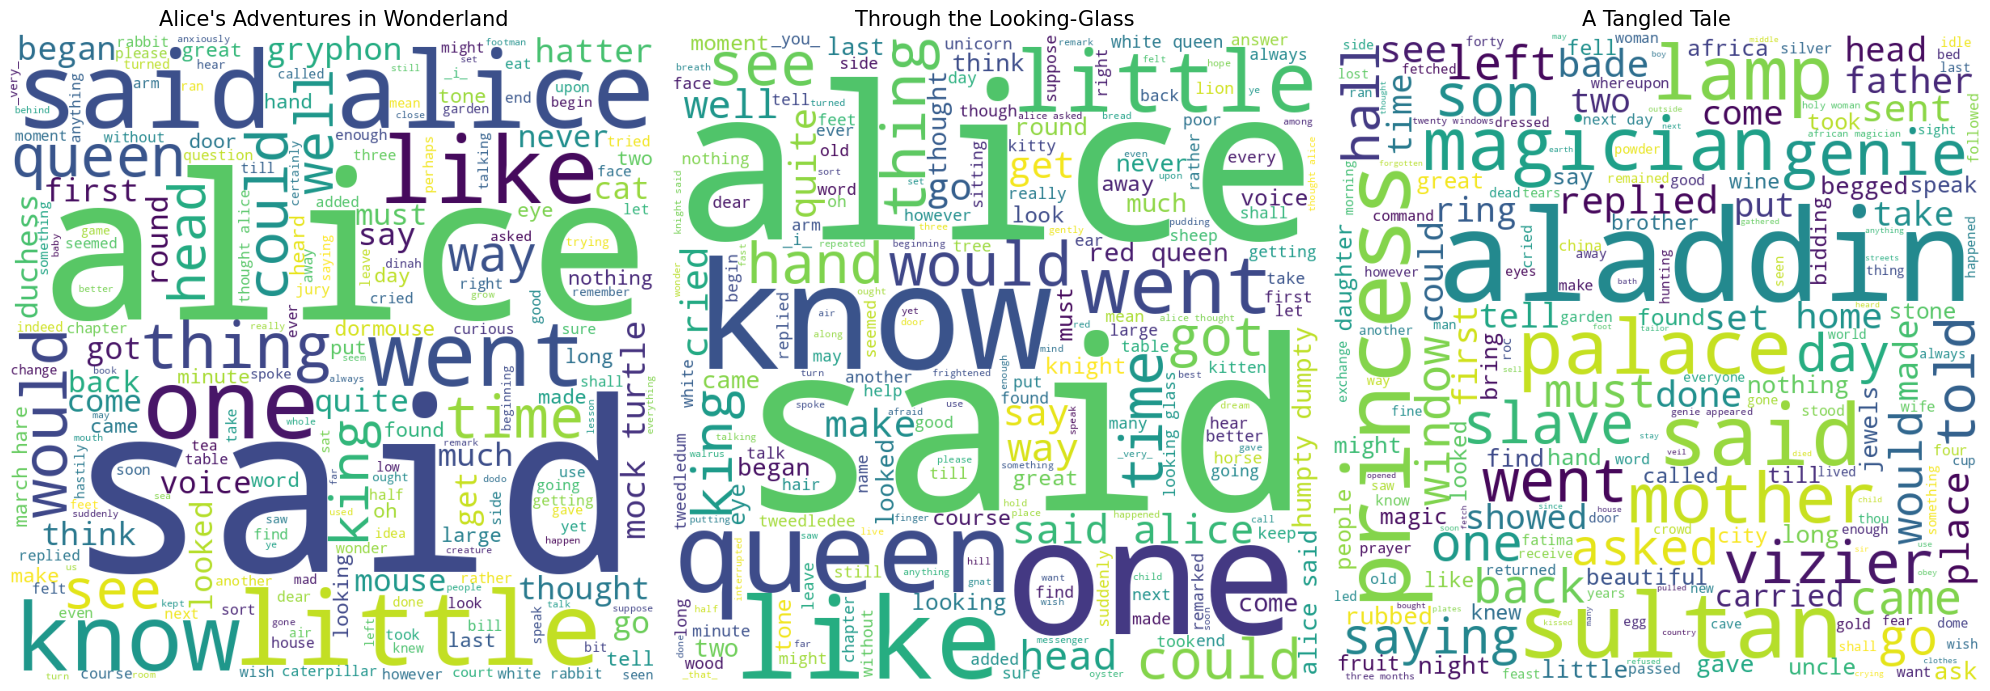

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
titles = ["Alice's Adventures in Wonderland", "Through the Looking-Glass", "A Tangled Tale"]

for i, text in enumerate(corpus):
    wordcloud = WordCloud(width=800, height=800, background_color='white', stopwords=stop_words, min_font_size=10).generate(text)
    axes[i].imshow(wordcloud)
    axes[i].set_title(titles[i], fontsize=15)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 2.2 Méthode Bag of Words (BoW) avec CountVectorizer

Nous utiliserons le texte **lemmatisé** car il regroupe les différentes formes d'un mot sous une forme unique et correcte, ce qui permet d'obtenir des statistiques de fréquence beaucoup plus précises que le texte brut ou racinisé.

In [14]:
# Préparation des données : conversion des listes de lemmes en chaînes de caractères
lemmatized_strings = [" ".join(text) for text in lemmatized_corpus]

# Initialisation du Vectoriseur BoW
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(lemmatized_strings)
feature_names = vectorizer.get_feature_names_out()

# Extraction des 5 mots les plus fréquents par livre
def get_top_n_words(matrix, feature_names, n=5):
    top_words = []
    for i in range(matrix.shape[0]):
        row = matrix.getrow(i).toarray()[0]
        top_indices = row.argsort()[-n:][::-1]
        top_words.append([(feature_names[idx], row[idx]) for idx in top_indices])
    return top_words

top_5_bow = get_top_n_words(bow_matrix, feature_names)

for i, words in enumerate(top_5_bow):
    print(f"\nLivre {i+1} - Top 5 BoW : {words}")


Livre 1 - Top 5 BoW : [('say', np.int64(481)), ('alice', np.int64(399)), ('think', np.int64(133)), ('go', np.int64(130)), ('little', np.int64(129))]

Livre 2 - Top 5 BoW : [('say', np.int64(491)), ('alice', np.int64(468)), ('queen', np.int64(202)), ('look', np.int64(153)), ('think', np.int64(139))]

Livre 3 - Top 5 BoW : [('aladdin', np.int64(100)), ('say', np.int64(50)), ('princess', np.int64(45)), ('sultan', np.int64(43)), ('magician', np.int64(32))]


### 2.3 Analyse de la matrice BoW

*   **Numéro du document :** Correspond à l'index de la ligne dans la matrice (0, 1 ou 2).
*   **Index du mot :** Correspond à la position du mot dans le dictionnaire créé par le vectoriseur (accessible via `get_feature_names_out()`).
*   **Fréquence :** La valeur stockée à l'intersection de la ligne (document) et de la colonne (index du mot).

### 2.4 Diagrammes circulaires des fréquences BoW

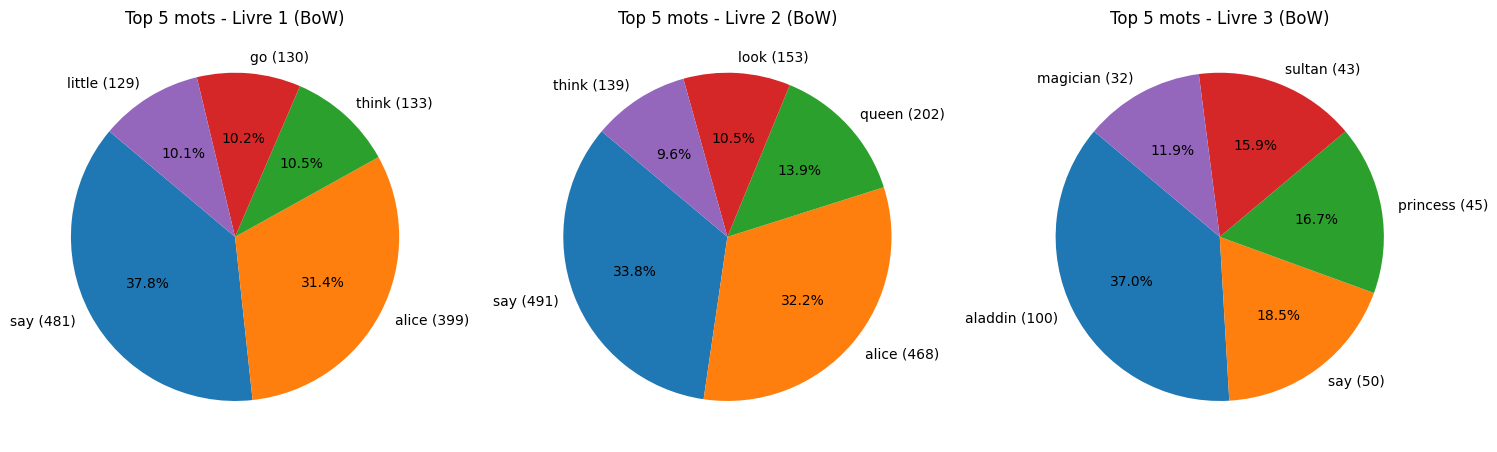

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, words in enumerate(top_5_bow):
    labels = [f"{w[0]} ({w[1]})" for w in words]
    sizes = [w[1] for w in words]
    axes[i].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
    axes[i].set_title(f"Top 5 mots - Livre {i+1} (BoW)")

plt.show()

### 2.5 Analyse des résultats BoW

Les mots identifiés par la méthode BoW (comme 'alice', 'say', 'go', 'think') sont **attendus** mais peu **informatifs**. Dans le cas d'Alice, son nom apparaît logiquement le plus souvent. Cependant, des verbes communs comme 'say' ou 'think' n'apportent pas de réelle valeur ajoutée pour comprendre le thème spécifique du livre par rapport aux autres livres de la même collection.

## Partie 3 — TF-IDF

### 3.1 & 3.2 Création du Vectoriseur TF-IDF et extraction des mots clés

In [16]:
# Initialisation du Vectoriseur TF-IDF
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2)
tfidf_matrix = tfidf_vectorizer.fit_transform(lemmatized_strings)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

# Extraction des 5 mots avec les meilleurs scores TF-IDF
top_5_tfidf = get_top_n_words(tfidf_matrix, tfidf_feature_names)

for i, words in enumerate(top_5_tfidf):
    print(f"\nLivre {i+1} - Top 5 TF-IDF : {words}")


Livre 1 - Top 5 TF-IDF : [('alice', np.float64(0.7991023947635291)), ('turtle', np.float64(0.16327033671270696)), ('queen', np.float64(0.15421274284910208)), ('mock', np.float64(0.15010337407458543)), ('hatter', np.float64(0.15010337407458543))]

Livre 2 - Top 5 TF-IDF : [('alice', np.float64(0.8058096122676897)), ('queen', np.float64(0.3478067129873362)), ('knight', np.float64(0.13810280131260724)), ('dumpty', np.float64(0.12678289956567224)), ('humpty', np.float64(0.12678289956567224))]

Livre 3 - Top 5 TF-IDF : [('aladdin', np.float64(0.7156086970213833)), ('princess', np.float64(0.3220239136596224)), ('sultan', np.float64(0.3077117397191948)), ('magician', np.float64(0.22899478304684265)), ('palace', np.float64(0.21468260910641496))]


### 3.3 Diagrammes circulaires TF-IDF

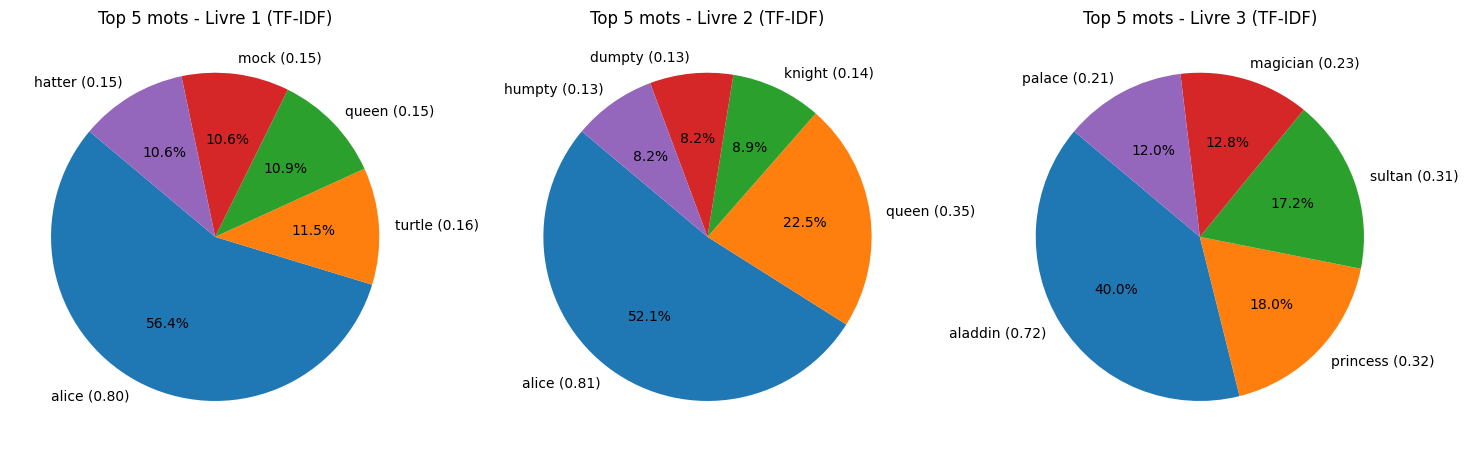

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, words in enumerate(top_5_tfidf):
    labels = [f"{w[0]} ({w[1]:.2f})" for w in words]
    sizes = [w[1] for w in words]
    axes[i].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
    axes[i].set_title(f"Top 5 mots - Livre {i+1} (TF-IDF)")

plt.show()

### 3.4 Comparaison BoW vs TF-IDF

**Pourquoi TF-IDF est-il plus représentatif ?**

Le **Bag of Words** ne compte que la fréquence brute. Ainsi, le nom 'Alice' domine partout car il est fréquent.

Le **TF-IDF** (Term Frequency-Inverse Document Frequency) pénalise les mots qui apparaissent dans tous les documents (max_df=2 exclut les mots présents dans les 3 livres). Cela permet de faire ressortir des mots **uniques** à chaque texte :
*   Pour 'Alice in Wonderland', on voit apparaître des termes plus spécifiques comme 'hatter' ou 'turtle'.
*   Pour 'Through the Looking-Glass', on voit 'humpty', 'dumpty' ou 'knight'.
*   Pour 'A Tangled Tale', on voit 'clara' ou 'mad' (dans un contexte différent).

En résumé, TF-IDF filtre le "bruit" commun au corpus pour souligner la **spécificité thématique** de chaque document.